<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/notebooks/07_GrangerCausality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Granger Causality 테스트 + VAR 모델을 이용한 Tesla 주가 예측 코드

📌 Granger Causality 테스트를 활용한 Tesla 주가 예측 방법  
1️⃣ Granger Causality 테스트 활용  
Granger Causality를 통해 Tesla 주가(종가)와 다른 변수(거래량, 시장 지수 등) 사이의 관계를 검정합니다.  
만약 특정 변수가 Tesla 주가를 Granger Causality 관계로 설명할 수 있다면, 해당 변수를 예측 모델의 피처(feature) 로 포함하여 예측 성능을 향상할 수 있습니다.  

2️⃣ VAR(Vector Autoregression) 모델을 활용한 예측  
Granger Causality 테스트를 통해 의미 있는 관계가 확인된 변수를 활용하여 VAR(벡터 자기회귀) 모델을 적용해 주가를 예측합니다.

### 🧭 실습 목표(Granger + VAR)
- ‘거래량이 가격을 예측하는가?’ 같은 질문을 **Granger causality**로 검정하고,
- 유의미하다고 판단되는 변수들을 묶어 **VAR**로 예측하는 흐름을 실습합니다.

### 0) 실습 속도 최적화(데이터 기간)
- 데이터는 **최근 1년(2025-03-30 ~ 2026-03-30)**만 사용합니다.

### 1) 왜 ‘레벨(Log_Close)’이 아니라 ‘변환(Log_Return)’을 쓰나?
- Granger/VAR는 기본적으로 **정상성(stationarity)** 가정이 필요합니다.
- 주가 ‘레벨(price level)’은 비정상인 경우가 많아서, 수업에서는 **로그수익률**로 변환합니다.

### 2) 핵심 수식(마크다운에서 안 깨지게 코드블록으로 표기)
로그수익률:
```text
Log_Return_t = log(Close_t) - log(Close_{t-1})
```
Granger 검정(개념):
```text
H0: X does NOT Granger-cause Y
=> (Y의 회귀식에서 X의 과거항 계수들이 모두 0)
```
VAR(p) 모형:
```text
y_t = c + A1 y_{t-1} + ... + Ap y_{t-p} + u_t
```


## ⚠️ 그렌저(Granger) 인과관계와 ‘주가예측’의 관계: 오해 방지 노트
그렌저 인과관계는 **경제적/구조적 인과(causal effect)**가 아니라, **예측 가능성(predictive content)**에 관한 검정입니다.

### 1) 그렌저 검정이 말하는 것(정확한 의미)
- 귀무가설 H0: “X의 과거값은 Y를 예측하는 데 **추가 정보가 없다**”
- H0가 기각되면: “X의 과거값이 Y 예측에 **추가 정보**를 제공한다”

즉, 그렌저는 ‘원인’이 아니라 **예측력의 추가성**을 검정합니다.

### 2) 왜 ‘유의’해도 예측이 좋아진다고 보장할 수 없나?
- **표본 내(in-sample) 유의성** ≠ **표본 외(out-of-sample) 성능**
- 시장은 **구조 변화(regime shift)**가 잦아 관계가 지속되지 않을 수 있음
- 변수/lag를 많이 돌리면 **다중검정(데이터 마이닝)**으로 우연 유의가 늘어남
- 공통요인(시장 충격) 때문에 ‘진짜 원인’이 아니어도 유의가 나올 수 있음

### 3) 수업에서 가장 안전한 연결 방식
그렌저는 ‘후보 변수 탐색’ 도구로 활용하고, 최종 판단은 반드시 **워크-포워드(rolling/expanding) 예측 성능**으로 확인합니다.
- 단변량(예: ARIMA) vs 다변량(예: VAR/ARIMAX) **OOS 성능 비교**
- 기간별 안정성(재현성) 점검

✅ 결론: 그렌저는 ‘예측과 무관’하지는 않지만, **예측 성능을 보장하는 도구는 아닙니다.**

Granger Causality Test
H0: Log_Volume_Diff does NOT Granger-cause Log_Return


,lag,F_stat,p_value,significant_5pct
0,1,2.197080,0.139558,False
1,2,4.359612,0.013802,True
2,3,5.192671,0.001715,True
3,4,4.313118,0.002190,True
4,5,3.719351,0.002939,True
5,6,3.161570,0.005339,True
6,7,3.327364,0.002155,True
7,8,2.688256,0.007678,True
8,9,2.425483,0.012030,True
9,10,2.180589,0.020008,True


Reject H0 at 5% for lag(s): [2, 3, 4, 5, 6, 7, 8, 9, 10]

Reverse test: Log_Return -> Log_Volume_Diff


,lag,F_stat,p_value,significant_5pct
0,1,2.675492,0.103188,False
1,2,1.286361,0.278157,False
2,3,1.251396,0.291803,False
3,4,1.122545,0.346505,False
4,5,0.936145,0.458240,False
5,6,0.938763,0.467922,False
6,7,0.708754,0.664647,False
7,8,0.653527,0.731975,False
8,9,1.050287,0.401068,False
9,10,1.425594,0.170269,False


Best VAR lag by AIC: 4
Test MSE: 5956.7600


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)


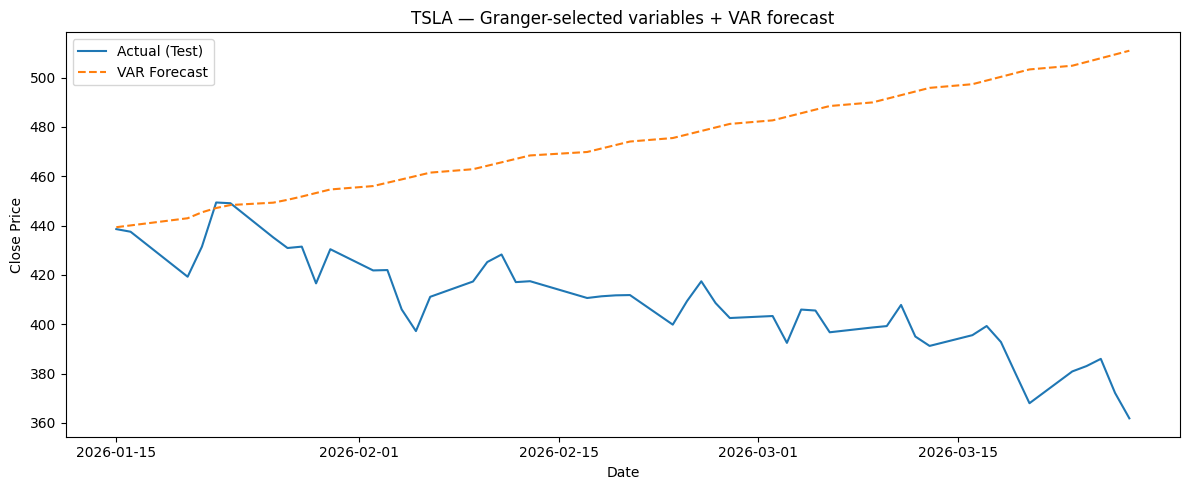

In [1]:
import io
import contextlib
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import grangercausalitytests
from sklearn.metrics import mean_squared_error

# 1) Data — MultiIndex safe
raw = yf.download(
    "TSLA",
    start="2025-03-30",
    end="2026-03-30",
    auto_adjust=True,
    progress=False
)

if raw.empty:
    raise RuntimeError("TSLA 데이터를 다운로드하지 못했습니다.")

def get_1d_field(df, field, ticker="TSLA"):
    if isinstance(df.columns, pd.MultiIndex):
        if (field, ticker) in df.columns:
            s = df[(field, ticker)]
        elif field in df.columns.get_level_values(0):
            s = df.xs(field, axis=1, level=0).iloc[:, 0]
        else:
            raise KeyError(f"{field} column not found.")
    else:
        if field not in df.columns:
            raise KeyError(f"{field} column not found.")
        s = df[field]
    return pd.to_numeric(s, errors="coerce")

close_s = get_1d_field(raw, "Close")
volume_s = get_1d_field(raw, "Volume")

df = pd.DataFrame({
    "Date": pd.to_datetime(raw.index),
    "Close": close_s.to_numpy(dtype=float),
    "Volume": volume_s.to_numpy(dtype=float)
}).dropna().reset_index(drop=True)

# 2) Features
df["Return"] = df["Close"].pct_change()
df["Log_Return"] = np.log(df["Close"]).diff()
df["Log_Close"] = np.log(df["Close"].replace(0, np.nan))
df["Log_Volume"] = np.log(df["Volume"].replace(0, np.nan))
df["Log_Volume_Diff"] = df["Log_Volume"].diff()
df = df.dropna().reset_index(drop=True)

# 3) Granger: Log_Volume_Diff -> Log_Return
max_lag = 10
gc_data = df[["Log_Return", "Log_Volume_Diff"]].dropna()

print("Granger Causality Test")
print("H0: Log_Volume_Diff does NOT Granger-cause Log_Return")

# 최신 statsmodels 호환: verbose 인자를 넘기지 않음
_stdout = io.StringIO()
with contextlib.redirect_stdout(_stdout):
    gc_results = grangercausalitytests(
        gc_data,
        maxlag=max_lag
    )

rows = []
for lag in range(1, max_lag + 1):
    f_stat, f_p, df_denom, df_num = gc_results[lag][0]["ssr_ftest"]
    rows.append({
        "lag": lag,
        "F_stat": float(f_stat),
        "p_value": float(f_p),
        "significant_5pct": bool(f_p < 0.05)
    })

granger_table = pd.DataFrame(rows)
display(granger_table)

if (granger_table["p_value"] < 0.05).any():
    print(
        "Reject H0 at 5% for lag(s):",
        granger_table.loc[
            granger_table["p_value"] < 0.05,
            "lag"
        ].tolist()
    )
else:
    print("Fail to reject H0 at 5% for all tested lags.")

# Reverse direction
gc_reverse = df[["Log_Volume_Diff", "Log_Return"]].dropna()
_stdout = io.StringIO()
with contextlib.redirect_stdout(_stdout):
    gc_results_rev = grangercausalitytests(
        gc_reverse,
        maxlag=max_lag
    )

rows_rev = []
for lag in range(1, max_lag + 1):
    f_stat, f_p, _, _ = gc_results_rev[lag][0]["ssr_ftest"]
    rows_rev.append({
        "lag": lag,
        "F_stat": float(f_stat),
        "p_value": float(f_p),
        "significant_5pct": bool(f_p < 0.05)
    })

print("\nReverse test: Log_Return -> Log_Volume_Diff")
display(pd.DataFrame(rows_rev))

# 4) VAR
data = (
    df[["Date", "Log_Return", "Log_Volume_Diff"]]
    .dropna()
    .set_index("Date")
)

train_size = int(len(data) * 0.8)
train = data.iloc[:train_size].copy()
test = data.iloc[train_size:].copy()

lag_results = VAR(train).select_order(
    maxlags=min(10, max(1, len(train) // 5))
)
best_lag = lag_results.aic
if best_lag is None or not np.isfinite(best_lag):
    best_lag = 1
best_lag = max(int(best_lag), 1)

print(f"Best VAR lag by AIC: {best_lag}")

model_fit = VAR(train).fit(best_lag)

test_pred = model_fit.forecast(
    train.to_numpy()[-best_lag:],
    steps=len(test)
)

test_pred_df = pd.DataFrame(
    test_pred,
    index=test.index,
    columns=["Log_Return_Pred", "Log_Volume_Diff_Pred"]
)

# 5) Price reconstruction
df_idx = df.set_index("Date")
prev_close = float(
    df_idx.loc[df_idx.index < test.index[0], "Close"].iloc[-1]
)
log_close0 = np.log(prev_close)

test_pred_df["Log_Close_Pred"] = (
    log_close0 + test_pred_df["Log_Return_Pred"].cumsum()
)
test_pred_df["Close_Pred"] = np.exp(test_pred_df["Log_Close_Pred"])

actual_close_test = df_idx.loc[test.index, "Close"].astype(float)
test_mse = mean_squared_error(
    actual_close_test,
    test_pred_df["Close_Pred"]
)
print(f"Test MSE: {test_mse:.4f}")

plt.figure(figsize=(12, 5))
plt.plot(
    actual_close_test.index,
    actual_close_test.values,
    label="Actual (Test)"
)
plt.plot(
    test_pred_df.index,
    test_pred_df["Close_Pred"].values,
    label="VAR Forecast",
    linestyle="--"
)
plt.title("TSLA — Granger-selected variables + VAR forecast")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.tight_layout()
plt.show()

### 🔎 출력 해석 포인트

첫 번째 검정의 귀무가설은

$$
H_0:
\text{Log Volume Difference does not Granger-cause Log Return}
$$

입니다.

각 lag별 `p_value`가 $0.05$보다 작으면 해당 lag에서 귀무가설을 기각합니다.

이 수정본은 `verbose` 옵션에 의존하지 않고,
`grangercausalitytests()`가 반환한 결과 객체에서 F-statistic과 p-value를 직접 표로 만듭니다.

Granger causality는 구조적 인과관계의 증명이 아니라
**예측정보의 선행성**을 검정하는 방법입니다.